# ML Project
#### Submitted By:
- **Niv Harel**: 208665869
- **Eytan Muzafi**: 209160308

#### Github: [https://github.com/nivrl/Machine-learning-project]

#### Unsupervised part 

In [1]:
import pandas as pd
import math
from datetime import datetime
import numpy as np
import re
import requests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [2]:
Behaviors= pd.read_excel("Behaviors.xlsx",index_col=0)  
Bins= pd.read_excel("Bins.xlsx",index_col=0)  
Infrastructures= pd.read_excel("Infrastructures.xlsx",index_col=0)   

In [3]:
Infrastructures = Infrastructures.reset_index()
Bins = Bins.reset_index()

In [4]:
bins_mapping = {
    'זמן סיום מהמערכת' : 'End_Time',
    'יישוב': 'City',
    'סמל_יישוב': 'City_Code',
    'שעת הגעה לנקודה': 'Arrival_Time',
    'נ.צ כתובת': 'Coordinate_Address',
    'כתובת תיאור מיקום נקודת המדידה': 'Measurement_Point_Description',
    'סוגנ קודת המדידה': 'Point_Type',
    'האם יש פחים בנקודת המדידה': 'Has_Bins',
    'כמה פחים יש בנקודת המדידה': 'Bin_Count',
    'סוג': 'Type',
    'מצב הפח': 'Bin_Condition',
    'מפלס הפסולת בפח': 'Waste_Level',
    'מפלס הפסולת בפח במספר': 'Waste_Level_Number'
}

infrastructures_mapping = {
    'זמןסיוםמהמערכת' : 'End_Time',
    'יישוב': 'City',
    'סמל_יישוב': 'City_Code',
    'שעתהגעהלנקודה': 'Arrival_Time',
    'נ.צכתובת': 'Coordinate_Address',
    'כתובתתיאורמיקוםנקודתהמדידה': 'Measurement_Point_Description',
    'התרשמותכלליתמנקודתהמדידה': 'General_Impression',
    'מדרכה': 'Sidewalk',
    'אבנישפה': 'Curb',
    'גדרות': 'Fences',
    'צמחייה': 'Vegetation',
    'הערות': 'Remarks',
    'point_type': 'Point_Type'
}

Behaviors_mapping = {
    'זמןסיוםמהמערכת' : 'End_Time',
    'יישוב': 'City',
    'סמל_יישוב': 'City_Code',
    'שעתהגעהלנקודה': 'Arrival_Time',
    'נ.צכתובת': 'Coordinate_Address',
    'כתובתתיאורמיקוםנקודתהמדידה': 'Measurement_Point_Description',
}


### First Data Cleaning & Organizing 

Take the relevant columns for each DF

In [5]:
bins_renamed = Bins.rename(columns=bins_mapping)
Behaviors_renamed = Behaviors.rename(columns=Behaviors_mapping)
infrastructures_renamed = Infrastructures.rename(columns=infrastructures_mapping)

In [6]:
Behaviors_renamed = Behaviors_renamed.drop(['City','gender','age','point_type','Arrival_Time','Coordinate_Address','time','parit','teortext','סוגנקודתהמדידהתשובה','Index1', 'heged1','heged2','heged3','heged4','heged5','heged6', 'heged7', 'heged8', 'heged9', 'heged10', 'heged11', 'heged12','heged13'], axis =1)
infrastructures_renamed = infrastructures_renamed.drop(['City', 'Arrival_Time','Coordinate_Address','Remarks'], axis=1)

In [7]:
Behaviors_renamed['teorshlilihiyuvi'] = Behaviors_renamed['teorshlilihiyuvi'].replace('שלילית', 'negative')
Behaviors_renamed['teorshlilihiyuvi'] = Behaviors_renamed['teorshlilihiyuvi'].replace('חיובית', 'positive')

#### Organizing the PKs for later merge: date, Measurement_Point_Description

In [8]:
Behaviors_renamed['Measurement_Point_Description'] = Behaviors_renamed['Measurement_Point_Description'].str.replace(r'[A-Za-z0-9_\n]', '', regex=True)
infrastructures_renamed['Measurement_Point_Description'] = infrastructures_renamed['Measurement_Point_Description'].str.replace(r'[A-Za-z0-9_\n]', '', regex=True)

In [9]:
Behaviors_renamed['End_Time'] = pd.to_datetime(Behaviors_renamed['End_Time'])
Behaviors_renamed['Date'] = Behaviors_renamed['End_Time'].dt.date

infrastructures_renamed['End_Time'] = pd.to_datetime(infrastructures_renamed['End_Time'])
infrastructures_renamed['Date'] = infrastructures_renamed['End_Time'].dt.date

In [10]:
Behaviors_renamed = Behaviors_renamed.drop(['End_Time'], axis =1)
infrastructures_renamed = infrastructures_renamed.drop(['End_Time'], axis =1)

#### Organizing the dateset: 
- From the Behaviors data, we want to know how many negative and positive behaviors there is per point and date
- For the infrastructures columns, we renamd the values to english for later use. And then fill the nuls in this columns by the most common value per city.
- For the bins dataset, we try to use the waste level columns, to add a more data about how each city refers to cleening in there public spaces.


In [11]:
Behaviors_renamed.isnull().sum()

City_Code                          0
Measurement_Point_Description      0
teorshlilihiyuvi                 245
Date                               0
dtype: int64

In [12]:
Behaviors_drops = Behaviors_renamed.dropna()

# we dont have a way to fill nulls in the main column 

In [13]:
# count how many negative / positive per row, and fill 0 where we dont have a data for negative / positive for a row
aggregated_behaviors = Behaviors_renamed.groupby(["City_Code", "Measurement_Point_Description", "Date"])["teorshlilihiyuvi"].value_counts().unstack(fill_value=0).reset_index()


In [14]:
aggregated_behaviors.sample(3)

teorshlilihiyuvi,City_Code,Measurement_Point_Description,Date,negative,positive
20,2,סביבת בית הכנסת והמכולת במושב טפחות,2021-07-20,0,1
1329,8500,אזור תעשייה רמלה מהצומת למפעל הנסון,2021-07-19,3,0
510,962,רח אלביאדר שכונה מערבית טובא זנגריה,2021-10-19,7,1


In [15]:
status_mapping_dict = {
    'לא תקין (מוזנח)': 'poor',
    'סביר': 'good',
    'תקין (מטופח)': 'great',
    'לא רלוונטי':  pd.NA 
}

columns_to_replace = ["Sidewalk", "Curb", "Fences", "Vegetation"]

infrastructures_renamed[columns_to_replace]=infrastructures_renamed[columns_to_replace].replace(status_mapping_dict)


In [16]:
most_common = infrastructures_renamed.groupby('City_Code')[["Sidewalk", "Curb", "Fences", "Vegetation"]].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None)
for col in ['Sidewalk', 'Curb', 'Fences', 'Vegetation']:
    infrastructures_renamed[col] = infrastructures_renamed.apply(
        lambda row: most_common.at[row['City_Code'], col] 
        if pd.isna(row[col]) and row['City_Code'] in most_common.index 
        else row[col], axis=1
    )

In [17]:
print(len(bins_renamed))
bins_renamed.isnull().sum()

2197


End_Time                            0
City                                0
City_Code                           0
Arrival_Time                        3
Coordinate_Address               1017
Measurement_Point_Description       0
Point_Type                          0
Has_Bins                            0
Bin_Count                         977
Type                              977
Bin_Condition                     977
Waste_Level                       977
Waste_Level_Number                977
dtype: int64

In [18]:
bins_grouped = bins_renamed.groupby('City_Code')[["Waste_Level_Number"]].agg(
    lambda x: x.mode().iloc[0] if not x.mode().empty else None)

In [19]:
bins_grouped.reset_index().isnull().sum()

City_Code             0
Waste_Level_Number    3
dtype: int64

In [20]:
data_for_unsupervised = infrastructures_renamed.dropna()

#### Merging DFs with inner joins 
In the final dateset there is:
-  Data about the **behaviors** in the city in terms of how many negative / positive behaves there is in the city.
-   Data about the **infrastructures statuses** in the city.

In [21]:
data_for_unsupervised = pd.merge(data_for_unsupervised, aggregated_behaviors, on=[
    "City_Code", "Measurement_Point_Description", "Date"], how='inner')	

In [22]:
data_for_unsupervised.shape

(1517, 11)

In [23]:
# We are triyng to add data about the mode 	Waste level in the bins in each city, but it significant reduce the model accuracy. 
# We think a good reason for this model behave its becuse this column have a lot of missing values, and it can cuse to unaccuracy results.
#data_for_unsupervised = pd.merge(data_for_unsupervised, bins_grouped, on=["City_Code"], how='left')	

### Start Working On Full Raw Data Set

#### Fetching dtypes

In [24]:
data_for_unsupervised.dtypes

City_Code                         int64
Measurement_Point_Description    object
General_Impression                int64
Sidewalk                         object
Curb                             object
Fences                           object
Vegetation                       object
Point_Type                       object
Date                             object
negative                          int64
positive                          int64
dtype: object

In [25]:
data_for_unsupervised['Date'] = pd.to_datetime(data_for_unsupervised['Date'])

In [26]:
for col in data_for_unsupervised.columns:
    if col not in ['Measurement_Point_Description', 'Point_Type']:
        if data_for_unsupervised[col].dtype not in ['int64', 'float64', 'datetime64[ns]']:
            data_for_unsupervised[col] = data_for_unsupervised[col].astype('category')

#### Handling overfitting and the rest of the Nulls

we are trying to fined a better way to To refer to cities and streets.

In [27]:
## Dates Fetching
data_for_unsupervised['Day_Of_Week'] = data_for_unsupervised.Date.dt.dayofweek
data_for_unsupervised['Month'] = data_for_unsupervised.Date.dt.month

data_for_unsupervised = data_for_unsupervised.drop(['Date'], axis=1)
data_for_unsupervised[['Month', 'Day_Of_Week']] = data_for_unsupervised[['Month', 'Day_Of_Week']] = data_for_unsupervised[['Month', 'Day_Of_Week']].astype('category')

In [28]:
## Fetching Point_type
data_for_unsupervised[['Point_Type']] = data_for_unsupervised[['Point_Type']].astype('category')


In [29]:
## City Fetching - Avoiding OverFitting
economical_status = pd.read_excel("economical_status.xlsx")  
economical_status = economical_status[economical_status['Unnamed: 2'].notnull()].reset_index()
economical_status = economical_status.iloc[1:, [2, 7, 9]]
columns_rename_e = ['City_Code','Area_code', 'Economical_Rate']
economical_status.columns = columns_rename_e
economical_status['Economical_Rate'] = economical_status['Economical_Rate'].astype('Float64')
economical_status = economical_status.groupby(['City_Code'], as_index=False).agg({'Economical_Rate': 'mean'})
economical_status

,City_Code,Economical_Rate
0,31,-0.869768
1,70,-0.236784
2,166,0.78359
3,168,0.79368
4,195,1.204407
...,...,...
76,9400,0.937315
77,9500,0.395968
78,9600,-0.437139
79,9700,1.516564


In [30]:
## Street Fetching - Avoiding OverFitting 

def classify_street(street):
    if any(keyword in street for keyword in ['דיין', 'הרצל', 'גוריון', 'רוטשילד', 'בגין', 'דיזינגוף']):
        return 'Main'
    if any(keyword in street for keyword in ['פארק', 'גן']):
        return 'Park'
    if any(keyword in street for keyword in ['קניון', 'מרכז מסחרי', 'שוק']):
        return 'Commercial'
    if any(keyword in street for keyword in ['תחנת דלק', 'תחנת רכבת']):
        return 'Transportation'
    if any(keyword in street for keyword in ['בית ספר', 'מתנ"ס', 'קופת חולים']):
        return 'Public Facility'
    if any(keyword in street for keyword in [
    'מכללת' , 'שדרה', 'דרך', 'מרכז', 'מכללה', 'טיילת', 'כיכר']):  
        return 'Popular'
    return 'Other'

data_for_unsupervised['Street_Group'] = data_for_unsupervised['Measurement_Point_Description'].apply(lambda x: classify_street(x))

data_for_unsupervised['Street_Group'].value_counts() ## We will try to see the result of the model with the 'Other' group.
## if the result will be poor, we will try to delete it.

Other              1088
Park                180
Popular              91
Commercial           90
Public Facility      39
Main                 24
Transportation        5
Name: Street_Group, dtype: int64

In [31]:
data_for_unsupervised.isnull().sum()

City_Code                        0
Measurement_Point_Description    0
General_Impression               0
Sidewalk                         0
Curb                             0
Fences                           0
Vegetation                       0
Point_Type                       0
negative                         0
positive                         0
Day_Of_Week                      0
Month                            0
Street_Group                     0
dtype: int64

#### Examine Outlires

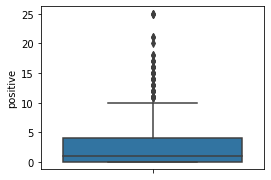

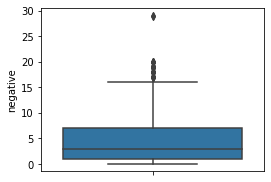

In [32]:
for col in ['positive', 'negative']:
    plt.figure(figsize=(4, 3))
    sns.boxplot(data=data_for_unsupervised, y=col)  
    plt.show()
## Doesn't seem like a daramatic outlires

In [33]:
data_for_unsupervised.to_excel('data_for_unsupervised.xlsx', index=False)
data= pd.read_excel("data_for_unsupervised.xlsx") 
data.head()

,City_Code,Measurement_Point_Description,General_Impression,Sidewalk,Curb,Fences,Vegetation,Point_Type,negative,positive,Day_Of_Week,Month,Street_Group
0,8500,רחוב זכריה,3,good,good,good,good,רחוב מגורים,0,6,2,7,Other
1,874,מגדל העמק רחוב הזית,4,poor,poor,great,poor,רחוב מסחרי,5,6,3,7,Other
2,874,רחוב הראשונים - שוק,4,great,great,great,good,רחוב מסחרי,6,0,3,7,Commercial
3,874,רחוב בוסקילה פארק משחקים (שניים סמוכים),2,great,great,great,good,פנאי ונופש,3,1,3,7,Park
4,874,פארק הראשונים - פנאי ונופש,3,great,great,great,great,פנאי ונופש,5,1,3,7,Park


- Drop out the columns that seem least important on the business side.
- We decided to do this now because after each categorical column becomes multiple columns, it will be harder for the PCA to pick the really important columns

In [34]:
data = data.drop(['City_Code','Measurement_Point_Description','Day_Of_Week','Street_Group','Point_Type'], axis=1)
data.dtypes

General_Impression     int64
Sidewalk              object
Curb                  object
Fences                object
Vegetation            object
negative               int64
positive               int64
Month                  int64
dtype: object

#### Encode category columns and normliza numeric columns.

In [35]:
def convert_categorial_by_encoder(X, categorical_cols):
    ohe = OneHotEncoder(drop='first',sparse_output=False) 
    encoded_categorical = ohe.fit_transform(X[categorical_cols])
    encoded_categorical_df = pd.DataFrame(encoded_categorical, columns=ohe.get_feature_names_out(categorical_cols))
    return encoded_categorical_df

In [36]:
def normlize_nomarical_features(X, numerical_cols):
    for col in numerical_cols:
        X[col] = (X[col] - X[col].min()) / (X[col].max() - X[col].min())
    return X[numerical_cols]

In [37]:
def normalize_and_encode (df_prepared):
    for col in ["Sidewalk","Month","Curb","Fences","Vegetation"]:
        df_prepared[col] = df_prepared[col].astype('category')
            
    numerical_cols = df_prepared.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df_prepared.select_dtypes(include=['category']).columns
    
    encoded_categorical_df=convert_categorial_by_encoder(df_prepared,categorical_cols)
    scaled_numerical_df=normlize_nomarical_features(df_prepared,numerical_cols)
    
    # Combine features
    df_processed = pd.concat([encoded_categorical_df, scaled_numerical_df], axis=1)
    
    df_processed = df_processed.dropna()

    return df_processed

In [38]:
final_df = normalize_and_encode(data)
final_df.to_excel('final_df_for_unsupervised.xlsx', index=False)
final_df.sample(2)


,Sidewalk_great,Sidewalk_poor,Curb_great,Curb_poor,Fences_great,Fences_poor,Vegetation_great,Vegetation_poor,Month_8,Month_9,Month_10,Month_11,General_Impression,negative,positive
409,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.103448,0.16
1492,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.5,0.034483,0.00


## Unsupervised Model

### How many clusterts we have? 

/Users/nivharel/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/nivharel/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/nivharel/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/nivharel/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_

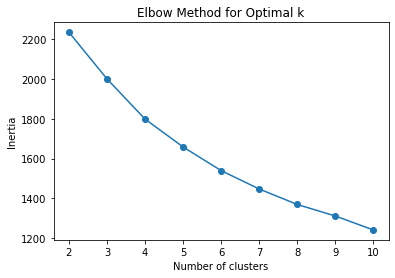

In [39]:
# The idea is from as. the code from GPT
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(final_df)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()



- We can see drematical changes from 6 to 7 in terns of accurecy. but after it, the changes looking not much. so we start aroud this number of clusters

### Dimensionality Reduction with PCA

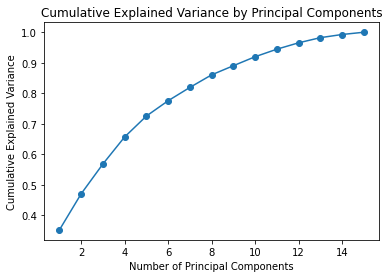

Number of columns in the original dataset: 15
Number of components explaining 85% of variance: 8


In [41]:
from sklearn.decomposition import PCA

data_scaled= final_df.copy()
# The idea is from as. the code from GPT
pca = PCA()
pca_data = pca.fit_transform(data_scaled)
explained_variance = pca.explained_variance_ratio_

# Plot cumulative explained variance
plt.figure()
plt.plot(range(1, len(explained_variance)+1), np.cumsum(explained_variance), marker='o')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

# Select the number of components that explain at least 85% of variance
num_components = np.argmax(np.cumsum(explained_variance) >= 0.85) + 1
print(f'Number of columns in the original dataset: {len(final_df.columns.tolist())}')
print(f'Number of components explaining 85% of variance: {num_components}')

# Reduce dimensions using PCA
pca_data_reduced = pca_data[:, :num_components]
reduced_df = pd.DataFrame(pca_data_reduced, columns=[f'PC{i+1}' for i in range(num_components)])

- We can see in the plot how many fetures we need for how many Cumulative variance .
- With the PCA we reduce 7 columns from the dataset

#### apply models and find the best model with silhouette_score

In [43]:
# The idea for the silhouette_score and the models is from as. the code from GPT
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, OPTICS
from sklearn.svm import OneClassSVM
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from itertools import product

# Define clustering models with hyperparameter tuning
model_params = {
    'KMeans': {'n_clusters': range(5, 8)},
    'DBSCAN': {'eps': [0.3, 0.5, 0.7], 'min_samples': [5, 10]},
    'AgglomerativeClustering': {'n_clusters': range(2, 11)},
    'GaussianMixture': {'n_components': range(2, 11)},
    'OPTICS': {'min_samples': [5, 10]}
}

results = []
for model_name, params in model_params.items():
    for param_combination in product(*params.values()):
        try:
            if model_name == 'KMeans':
                model = KMeans(n_clusters=param_combination[0], random_state=42)
            elif model_name == 'DBSCAN':
                model = DBSCAN(eps=param_combination[0], min_samples=param_combination[1])
            elif model_name == 'AgglomerativeClustering':
                model = AgglomerativeClustering(n_clusters=param_combination[0])
            elif model_name == 'GaussianMixture':
                model = GaussianMixture(n_components=param_combination[0], random_state=42)
            elif model_name == 'OPTICS':
                model = OPTICS(min_samples=param_combination[0])
            
            labels = model.fit_predict(reduced_df)
            if len(set(labels)) > 1:
                silhouette = silhouette_score(reduced_df, labels)
            else:
                silhouette =  -1
            
            results.append({
                'Model': model_name,
                'Parameters': param_combination,
                'Silhouette Score': silhouette
            })
        except Exception as e:
            print(f'Error with {model_name} and params {param_combination}: {e}')

# Display model evaluation results
results_df = pd.DataFrame(results)
results_df

/Users/nivharel/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/nivharel/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/nivharel/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/Users/nivharel/opt/anaconda3/lib/python3.8/site-packages/sklearn/cluster/_optics.py:995: RuntimeWarning: divide by zero encounter

,Model,Parameters,Silhouette Score
0,KMeans,"(5,)",0.282184
1,KMeans,"(6,)",0.305773
2,KMeans,"(7,)",0.317662
3,DBSCAN,"(0.3, 5)",0.629702
4,DBSCAN,"(0.3, 10)",0.412032
5,DBSCAN,"(0.5, 5)",0.673001
6,DBSCAN,"(0.5, 10)",0.510251
7,DBSCAN,"(0.7, 5)",0.619818
8,DBSCAN,"(0.7, 10)",0.528238
9,AgglomerativeClustering,"(2,)",0.300327


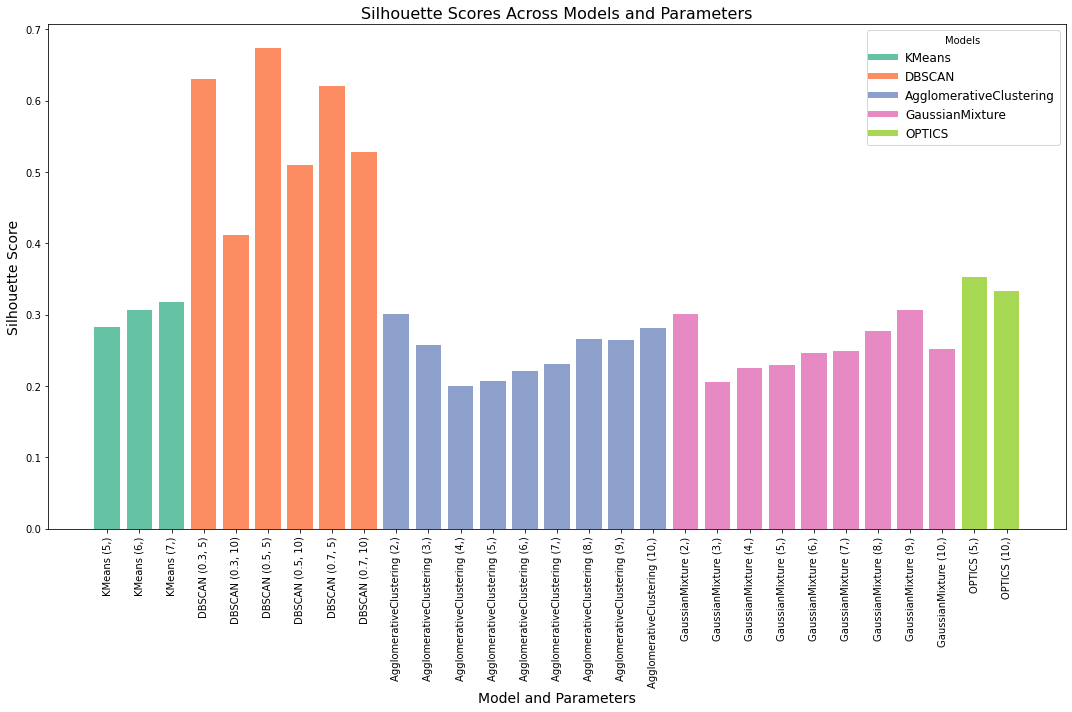

In [44]:
# GPT
results_df['Parameters_plots'] = results_df['Parameters'].astype(str)

# Combine 'Model' and 'Parameters' into a single column for labeling
results_df['Model_Params'] = results_df['Model'] + " " + results_df['Parameters_plots']

# Create a color mapping for each model
models = results_df["Model"].unique()
colors = plt.cm.Set2(range(len(models)))  # Use a colormap (e.g., tab10) for distinct colors
color_map = dict(zip(models, colors))  # Map each model to a specific color

# Plot
plt.figure(figsize=(15, 10))
bars = plt.bar(
    results_df["Model_Params"], 
    results_df["Silhouette Score"], 
    color=[color_map[model] for model in results_df["Model"]]  # Assign colors based on the model
)

# Add title and labels
plt.title("Silhouette Scores Across Models and Parameters", fontsize=16)
plt.xlabel("Model and Parameters", fontsize=14)
plt.ylabel("Silhouette Score", fontsize=14)

# Rotate x-axis labels for better readability
plt.xticks(rotation=90, fontsize=10)

# Add a legend for the models
legend_patches = [plt.Line2D([0], [0], color=color_map[model], lw=6, label=model) for model in models]
plt.legend(handles=legend_patches, title="Models", fontsize=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


Best Model: DBSCAN with Parameters: (0.5, 5) and Silhouette Score: 0.673000635597724


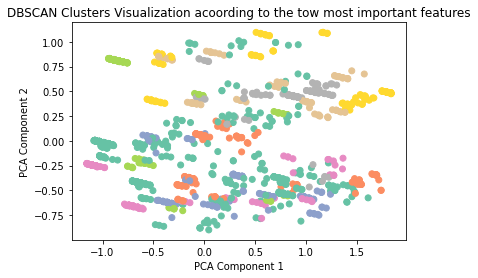

In [45]:
# Select the best model based on Silhouette Score
best_model = results_df.sort_values(by='Silhouette Score', ascending=False).iloc[0]
print(f"Best Model: {best_model['Model']} with Parameters: {best_model['Parameters']} and Silhouette Score: {best_model['Silhouette Score']}")

# Train the best model
best_model_name = best_model['Model']
best_params = best_model['Parameters']
if best_model_name == 'KMeans':
    final_model = KMeans(n_clusters=best_params[0], random_state=42)
elif best_model_name == 'DBSCAN':
    final_model = DBSCAN(eps=best_params[0], min_samples=best_params[1])
elif best_model_name == 'AgglomerativeClustering':
    final_model = AgglomerativeClustering(n_clusters=best_params[0])
elif best_model_name == 'GaussianMixture':
    final_model = GaussianMixture(n_components=best_params[0], random_state=42)
elif best_model_name == 'OPTICS':
    final_model = OPTICS(min_samples=best_params[0])

final_labels = final_model.fit_predict(reduced_df)
reduced_df['Cluster'] = final_labels

# Visualize the final clusters
plt.figure()
plt.scatter(pca_data_reduced[:, 0], pca_data_reduced[:, 1], c=reduced_df['Cluster'], cmap='Set2')
plt.title(f'{best_model_name} Clusters Visualization acoording to the tow most important features')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

We accept a DBSCAN model with:
-  0.5 epsilon (the maximum distance between tow points)
- 5 is the minimum number of points that need to be together to be considered a group